# Assignment 2: Time Series Prediction of Sepsis

Authors: Fredrik Boglind

In [1]:
import sys
import os

# Ensure current working directory is where the notebook is located
notebook_dir = os.path.dirname(os.path.abspath("__file__")) if '__file__' in globals() else os.getcwd()
sys.path.append(notebook_dir)
# Add the parent directory to the system path
sys.path.insert(0, os.path.abspath(".."))


In [2]:
# Imports
import pandas as pd
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
#from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
#from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

from model import AttentionLSTM
from custom_datasets import SepsisDataset, prepare_all_sequences, create_sequences_for_classification
from training_pipeline import train_all_models, print_results_summary, train_auc_wrapper, run_feature_ablation
from utility_functions import save_all_results, load_all_results, plot_ablation_results, visualize_attention_weights,\
analyze_errors, analyze_class_distribution, analyze_thresholds, plot_feature_distributions,plot_model_comparison,\
plot_temporal_patterns

In [3]:
#Set up directories
DATA_DIR = '../raw_data/' #Contains datafiles from SepsisExp/
MODELS_DIR = '../models/'
OUT_DIR = '../processed_data/'

In [4]:
# Set options and check for GPU
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## Load Data

In [ ]:
data_A = pd.read_csv(f'{DATA_DIR}/sepsisexp_timeseries_partition-A.tsv', sep='\t')
data_B = pd.read_csv(f'{DATA_DIR}/sepsisexp_timeseries_partition-B.tsv', sep='\t')
data_C = pd.read_csv(f'{DATA_DIR}/sepsisexp_timeseries_partition-C.tsv', sep='\t')
data_D = pd.read_csv(f'{DATA_DIR}/sepsisexp_timeseries_partition-D.tsv', sep='\t')

# Combine training data
train_data = pd.concat([data_A, data_B, data_C], ignore_index=True)
test_data = data_D

sequences = prepare_all_sequences(train_data, test_data)


Creating sequences for 2-hour early detection...
  Training sequences: 4785 from 957 patients
  Test sequences: 1590 from 318 patients
  Positive class ratio - Train: 0.232, Test: 0.233

Creating sequences for 4-hour early detection...
  Training sequences: 4785 from 957 patients
  Test sequences: 1590 from 318 patients
  Positive class ratio - Train: 0.232, Test: 0.233

Creating sequences for 6-hour early detection...
  Training sequences: 4785 from 957 patients
  Test sequences: 1590 from 318 patients
  Positive class ratio - Train: 0.232, Test: 0.233


In [6]:
# Display some basic information for each partition and view columns
print("Data shapes:")
print(f"Partition A: {data_A.shape}")
print(f"Partition B: {data_B.shape}")
print(f"Partition C: {data_C.shape}")
print(f"Partition D: {data_D.shape}")

print("\nColumns:")
for column in data_A.columns.tolist():
    print(column)


Data shapes:
Partition A: (156704, 47)
Partition B: (152155, 47)
Partition C: (156219, 47)
Partition D: (137490, 47)

Columns:
id
sepsis
severity
timestep
respiratory_minute_volume
heart_rate
leukocytes
temperature
partial_co2
respiratory_rate
arterial_ph
bilirubin
blood_urea_nitrogen
creatinine
diastolic_bp
fraction_of_inspired_o2
mean_bp
partial_pressure_art._o2
systolic_bp
thrombocytes
horowitz_index
bun/creatinine_ratio
delta-temperature
lactate
bicarbonate
c-reactive_protein
hemoglobin
heart_time_volume
lymphocytes
sodium
pancreatic_lipase
procalcitonin
quick_score
oxygen_saturation
blood_glucose
base_excess
chloride
calcium
potassium
mixed_venous_oxygen_saturation
urine_output
net balance
alanine_transaminase
aspartate_transaminase
stroke_volume
svri
age


## Task 1: **Exploring the data and Training of Base Model**

### 1.1: Exploratory Data Analysis

The sepsis label does not change over time for each patient:

In [7]:
# Verify sepsis labels are constant per patient
print("\nVerifying sepsis labels...")
for name, data in [('A', data_A), ('B', data_B), ('C', data_C), ('D', data_D)]:
    sepsis_variance = data.groupby('id')['sepsis'].std()
    print(f"Partition {name} - Patients with changing sepsis status: {(sepsis_variance > 0).sum()}")


Verifying sepsis labels...
Partition A - Patients with changing sepsis status: 0
Partition B - Patients with changing sepsis status: 0
Partition C - Patients with changing sepsis status: 0
Partition D - Patients with changing sepsis status: 0


Thus, the task is not predicting sepsis onset time but rather classifying whether a patient has sepsis or not, based on their time series data.

The dataset exhibits class imbalance:

In [8]:
# Analyze patient distribution for the training data
print("\nPatient distribution:")
train_patients = train_data.groupby('id')['sepsis'].first()
test_patients = test_data.groupby('id')['sepsis'].first()
print(f"Training: {len(train_patients)} patients, {train_patients.sum()} with sepsis ({train_patients.mean():.1%})")
print(f"Test: {len(test_patients)} patients, {test_patients.sum()} with sepsis ({test_patients.mean():.1%})")


Patient distribution:
Training: 957 patients, 222 with sepsis (23.2%)
Test: 318 patients, 74 with sepsis (23.3%)



### 1.2. Neural Network Architectures
**Model choice**
The *bidirectional* architecture allows for capturing both past and future context within each sequence. The *attention mechanism* allows the model to dynamically focus on the most relevant timesteps within a sequence and allows for a bigger context window than simpler models.
**Model Architecture**
Model Architecture

- Layers:
    - 2 layers, each with a hidden size of 128
    - Bidirectional for capturing forward and backward dependencies
    - Dropout of 0.3 applied between layers to prevent overfitting

- Attention Layer:
    - A small feed-forward network that outputs attention weights for each timestep
    - Softmax normalization is used

- Classifier (Feedforward MLP):
    - Linear(256 → 128) + ReLU + Dropout(0.3)
    - Linear(128 → 64) + ReLU + Dropout(0.3)
    - Linear(64 → 1) + Sigmoid
- Output:
    - A sigmoid-activated scalar in [0,1] showing the predicted probability of sepsis onset


```
class AttentionLSTM(nn.Module):
    """LSTM with attention for sepsis classification"""
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.3):
        super(AttentionLSTM, self).__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )
        
        self.attention = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
```



Pretrained models and results are available:

In [22]:
# Load pretrained models with results and results from feature ablation

# Results (data from pickle files)
main_results, ablation_results = load_all_results(MODELS_DIR)

# Models
model_2h = AttentionLSTM(input_size=43)
model_2h.load_state_dict(torch.load(f'{MODELS_DIR}/model_2h.pth'))
model_4h = AttentionLSTM(input_size=43)
model_4h.load_state_dict(torch.load(f'{MODELS_DIR}/model_4h.pth'))
model_6h = AttentionLSTM(input_size=43)
model_6h.load_state_dict(torch.load(f'{MODELS_DIR}/model_6h.pth'))


Results loaded successfully!


<All keys matched successfully>

### 1.3. Training Strategy

The training strategy included:
- Adam optimizer with learning rate scheduling
- Early stopping to prevent overfitting
- Class weighting to handle imbalanced data
- Validation-based model selection

Optimizer & Loss Function
- Adam optimizer with a learning rate of 0.001 was used since it was deemed well-suited for time series problems with noisy gradients.

- The Binary Cross-Entropy Loss (BCELoss) was used - appropriate for binary classification tasks like predicting sepsis onset (yes/no).

Learning Rate Scheduler
- A ReduceLROnPlateau scheduler monitored the validation AUC and halves the learning rate when performance stagnated for 5 consecutive epochs. This was meant to encourage convergence after initial rapid learning.

Early Stopping
- To prevent overfitting, early stopping halted training if the validation AUC failed to improve for 10 epochs (patience = 10).

Epochs and Batch Size
- Each model is trained for up to 50 epochs.
- The batch size is fixed at 32 (For feature ablation experiments, the batch size to 64 to reduce runtime)

Evaluation During Training
- After each epoch, both training and validation AUC scores are computed and stored.
- This allows for model selection based on generalization performance rather than just loss minimization.

```
    @staticmethod
    def train_model(model, train_loader, val_loader, epochs=50, lr=0.001):
```

In [11]:
# No need to train, you can use the pretrained models
#main_results = train_all_models(sequences, AttentionLSTM, prediction_hours=[2, 4, 6], epochs=50)

These are the results of the initial training


SUMMARY - Early Detection Performance
Hours Before End | AUC    | Accuracy | Recall | F1-Score
------------------------------------------------------------
       2         | 0.7370 | 0.7591   | 0.4216 | 0.4489
       4         | 0.7261 | 0.7654   | 0.4108 | 0.4490
       6         | 0.7099 | 0.7748   | 0.4757 | 0.4958


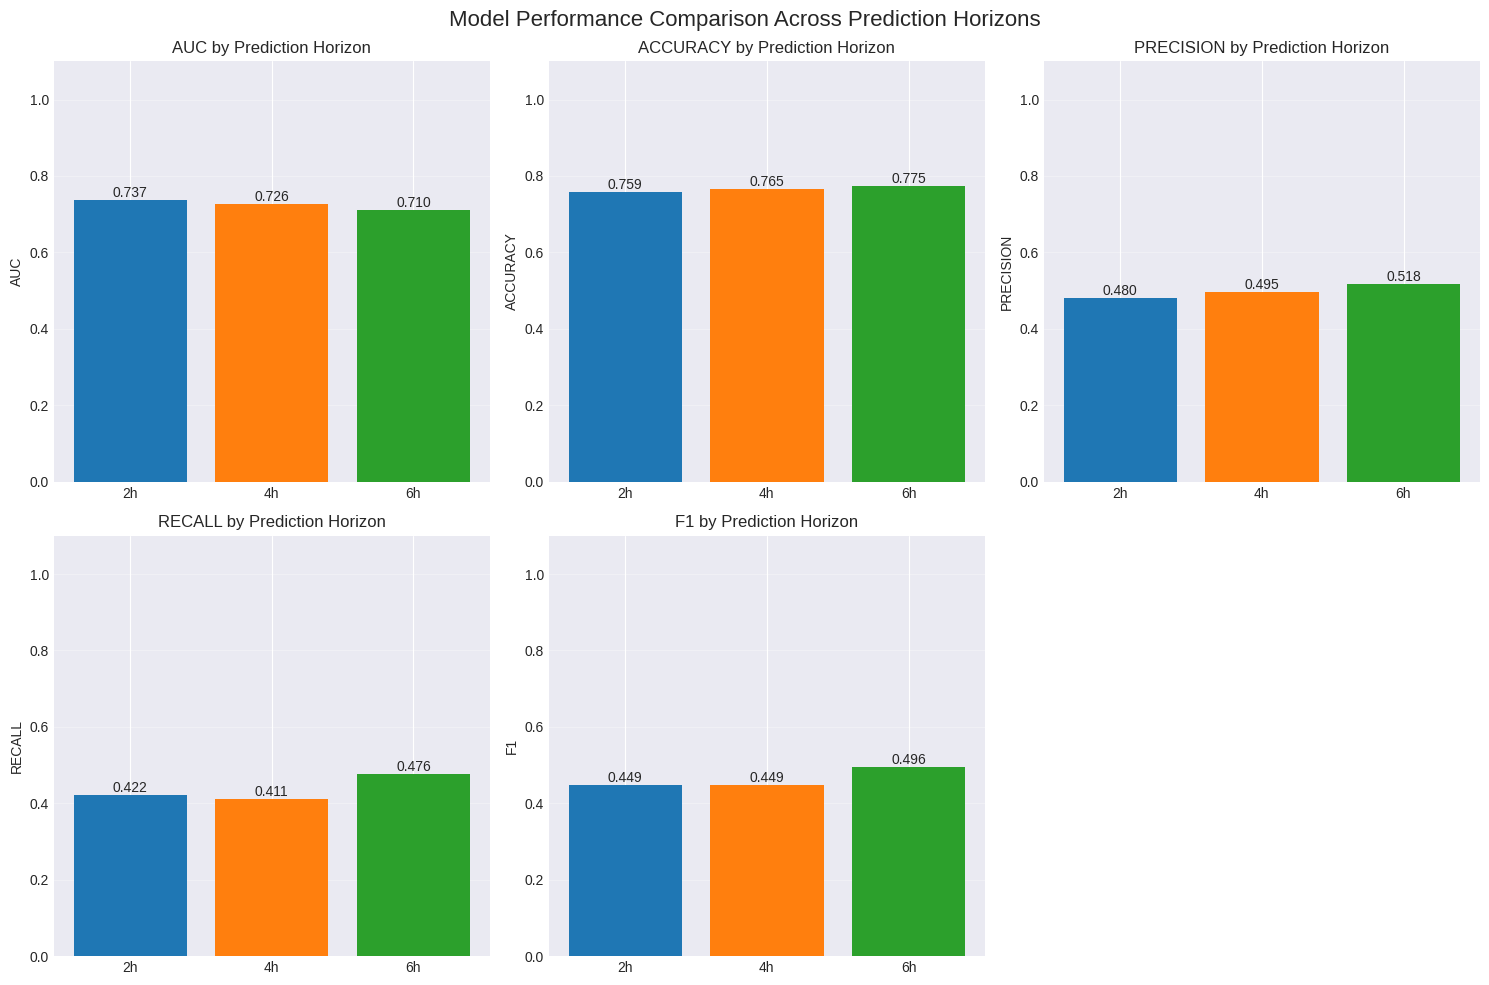

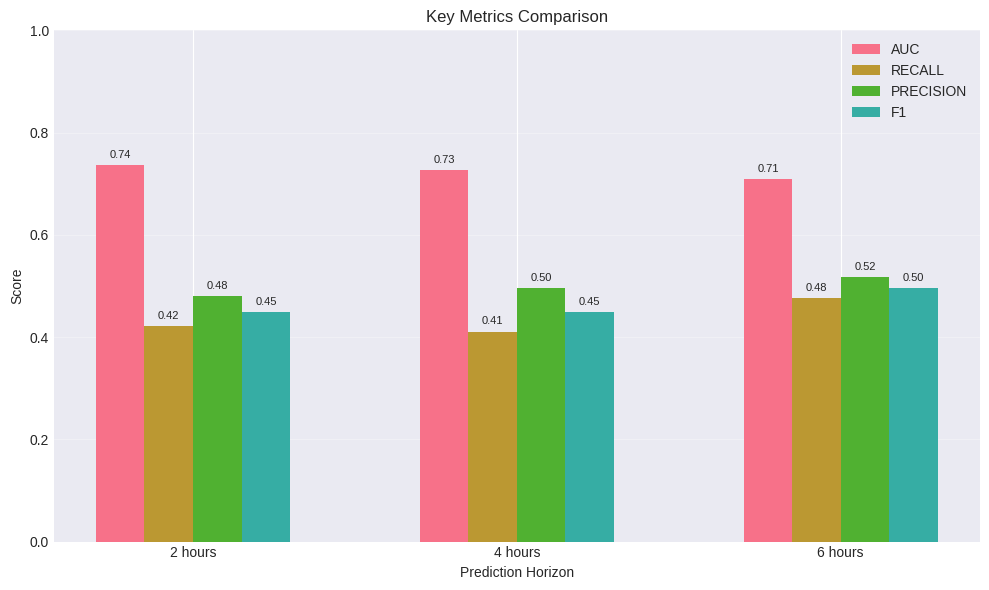

In [12]:
# Summary
print("\n" + "="*60)
print("SUMMARY - Early Detection Performance")
print("="*60)
print("Hours Before End | AUC    | Accuracy | Recall | F1-Score")
print("-"*60)
for hours in [2, 4, 6]:
    r = main_results[hours]
    print(f"{hours:^16} | {r['auc']:.4f} | {r['accuracy']:.4f}   | {r['recall']:.4f} | {r['f1']:.4f}")

plot_model_comparison(main_results)

### 1.5. Evaluation metrics

A combination of threshold-independent and threshold-dependent metrics was used:
- **ROC-AUC** (Area Under the Receiver Operating Characteristic Curve)
    - Pimary evaluation metric.
    - Threshold-independent and insensitive to class imbalance (common in clinical data).
    - Here it was used to evaluates the model's ability to distinguish between septic and non-septic cases across all classification thresholds.

- **Recall**, **Precision** and **F1 Score**
    - Commonly used metrics for error analysis
    - The ~1:3 ratio of sepsis to non-sepsis patients in the dataset makes these metrics particulary relevant - a model that simply predicts "no sepsis" for everyone would achieve 77% accuracy but miss all sepsis cases.
    - The balance precision and recall is important in clinical settings where both false negatives and false positives can have significant consequences.


- **Threshold Analysis**
    - Performance was evaluated across thresholds (0.1 to 0.9) to visualize the F1/Recall/Precision trade-off.

### 1.6 Error Analysis
Error analysis was performed to see what type of mistakes the model makes in its predictions


In [13]:
analyze_errors(main_results,threshold=0.5)

ERROR ANALYSIS

2-hour prediction (threshold=0.5):
  True Positives:  156 (9.8%)
  True Negatives:  1051 (66.1%)
  False Positives: 169 (10.6%) - False alarms
  False Negatives: 214 (13.5%) - Missed cases
  → Model is too conservative (missing too many sepsis cases)

4-hour prediction (threshold=0.5):
  True Positives:  152 (9.6%)
  True Negatives:  1065 (67.0%)
  False Positives: 155 (9.7%) - False alarms
  False Negatives: 218 (13.7%) - Missed cases
  → Model is too conservative (missing too many sepsis cases)

6-hour prediction (threshold=0.5):
  True Positives:  176 (11.1%)
  True Negatives:  1056 (66.4%)
  False Positives: 164 (10.3%) - False alarms
  False Negatives: 194 (12.2%) - Missed cases
  → Model is too conservative (missing too many sepsis cases)


All models show conservative behavior:
- **False Negative Rate**: 12-14% (missed sepsis cases)
- **False Positive Rate**: ~10% (false alarms)
- **Clinical Implication**: Models err on the side of caution

The 6-hour prediction model achieves the best balance with 11.1% true positives vs 9.6-9.8% for shorter horizons.

## Task 2: **Feature Importance Analysis**
Two complementary approaches were used to analyze feature importance:
- Leave-one-feature-out ablation
- Attention weight visualization.

(To train the ablation models, uncomment the code blocks below and run them, otherwise the results can be viewed below)

In [14]:
# # Run feature ablation on combined training data
# all_features = [col for col in train_data.columns if col not in ['id', 'sepsis', 'severity', 'timestep']]
# ablation_results = []

# for interval in [2, 4, 6]:
#     ablation_result = run_feature_ablation(
#         df=train_data,
#         feature_cols=all_features,
#         create_fn=create_sequences_for_classification,
#         train_fn=train_auc_wrapper,
#         lookback_hours=6,
#         prediction_ahead_hours=interval,
#         device='cuda' # 'cpu'
#     )

#     ablation_results.append(ablation_result)
#     print(ablation_result.head(10))

In [15]:
## Save all results (no need to do this if using pretrained models)
# save_all_results(main_results, ablation_results, OUT_DIR)

### 2.1 Leave-One-Feature-Out Ablation

Ablation analysis is helpful to understand which biomarkers to monitor most closely by omitting featues and measure the effect on a models prediction abilities.

A systematic ablation analysis was performed by retraining models while omitting one feature at a time. The drop in AUC (ΔAUC) was used to assess the importance of each feature.

**Two-hour Prediction**
    - Most impactful feature: `leukocytes` (ΔAUC = 0.056)
    - Other important features: `heart_rate`, `temperature`, `stroke_volume`, `respiratory_minute_volume`

In [16]:
print(ablation_results[0].head(10))
#plot_ablation_results(ablation_results[0],2)

                           Feature  AUC_without  Delta_AUC
2                       leukocytes     0.768665   0.055991
39          aspartate_transaminase     0.799641   0.025014
14                     systolic_bp     0.804652   0.020004
19                         lactate     0.805494   0.019161
3                      temperature     0.808093   0.016562
1                       heart_rate     0.808292   0.016363
40                   stroke_volume     0.809046   0.015609
0        respiratory_minute_volume     0.809478   0.015177
35  mixed_venous_oxygen_saturation     0.809653   0.015003
8              blood_urea_nitrogen     0.810112   0.014543


**Four-hour Prediction** - Top features: pancreatic_lipase, heart_rate, respiratory_minute_volume, thrombocytes, delta-temperature



In [17]:
print(ablation_results[1].head(10))
#plot_ablation_results(ablation_results[1],4)

                      Feature  AUC_without  Delta_AUC
26          pancreatic_lipase     0.803000   0.023926
1                  heart_rate     0.803803   0.023123
0   respiratory_minute_volume     0.806607   0.020319
32                   chloride     0.808822   0.018104
11    fraction_of_inspired_o2     0.811375   0.015551
15               thrombocytes     0.812202   0.014724
18          delta-temperature     0.812579   0.014347
8         blood_urea_nitrogen     0.814687   0.012239
23          heart_time_volume     0.816731   0.010195
3                 temperature     0.817099   0.009827


**Six-hour Prediction**: Top features: heart_time_volume, horowitz_index, arterial_ph, base_exces

In [18]:
print(ablation_results[2].head(10))
#plot_ablation_results(ablation_results[2],6)

              Feature  AUC_without  Delta_AUC
23  heart_time_volume     0.805022   0.016388
16     horowitz_index     0.807575   0.013835
6         arterial_ph     0.807688   0.013722
31        base_excess     0.808442   0.012968
24        lymphocytes     0.814669   0.006741
42                age     0.816900   0.004511
9          creatinine     0.817767   0.003643
30      blood_glucose     0.818361   0.003049
36       urine_output     0.818781   0.002629
4         partial_co2     0.820522   0.000889


The results show that **vital signs** and **inflammation markers** are consistently important across the time horizons and that some metabolic and cardiovascular features gradually gain importance as the prediction window increases.

### 2.2 Attention Weight Visualization

To understand what parts of the time series the model focuses on, the attention weights for selected patients was visualized:

- The model often assigned peak attention to the middle or later timesteps in the sequence, suggesting that recent measurements (close to the prediction point) are particularly informative.

- The top features at the timestep of maximum attention weight, align with medically relevant variables like heart_rate, lactate, and temperature.

This confirms that the model is not only learning to use temporal trends but also prioritizes interpretable clinical signals.



Patient 0:


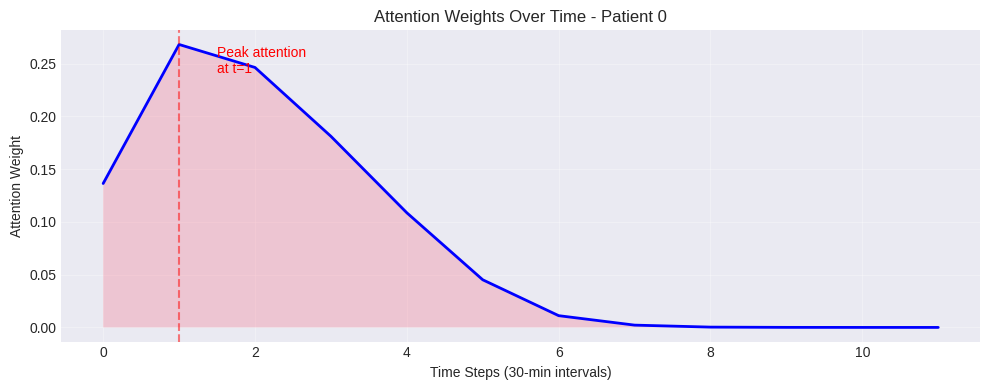


At peak attention time (t=1):
Top features by value:
  creatinine: 3.789
  base_excess: -2.860
  calcium: 2.708
  partial_pressure_art._o2: 2.396
  horowitz_index: 2.070

Patient 10:


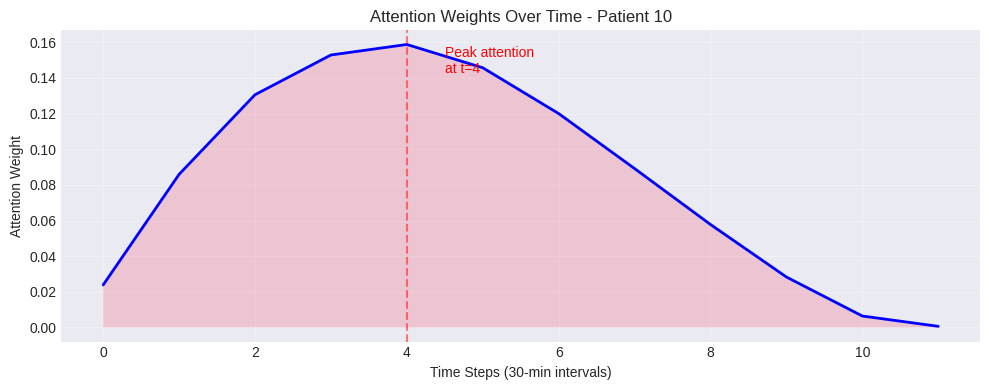


At peak attention time (t=4):
Top features by value:
  base_excess: -2.979
  arterial_ph: -2.014
  quick_score: -1.910
  chloride: 1.527
  oxygen_saturation: -1.417

Patient 20:


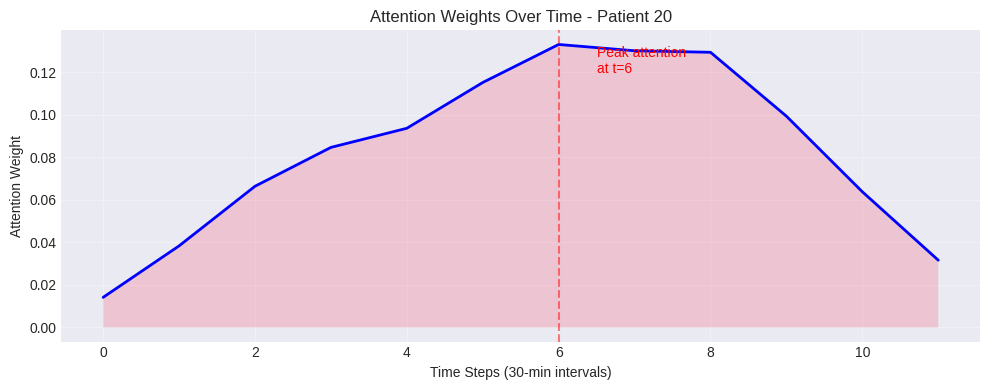


At peak attention time (t=6):
Top features by value:
  base_excess: -2.141
  quick_score: -1.910
  heart_rate: -1.762
  diastolic_bp: -1.703
  hemoglobin: 1.474


In [19]:
# Visualize attention for a few patients
for patient_idx in [0, 10, 20]:  # Sample patients
    print(f"\nPatient {patient_idx}:")
    visualize_attention_weights(model_4h, sequences[4]['X_test'], feature_cols, device, patient_idx)


### 2.3. Distributional Differences

Feature distributions between septic and non-septic patients was analyzed. For example:

| Feature                    | Median (No Sepsis) | Median (Sepsis) |
|----------------------------|--------------------|------------------|
| Respiratory Minute Volume | -0.47              | -0.04            |
| Heart Rate                | -0.50              | -0.01            |
| Temperature               | -0.17              | -0.06            |
| Leukocytes                | -0.32              | -0.19            |
| Partial CO₂               | -0.42              | -0.33            |
| Respiratory Rate          | -0.69              | -0.17            |

The shifts show differences between sepsis and non-sepsis patients.

### 2.4 Analysis of Ablation Results

- Which features are most critical (largest Δ AUC when removed)

- Do the important features align with clinical knowledge? (e.g., vital signs, lab values)

- Are there differences in feature importance across prediction horizons?

In [20]:
# Create summary of most important features
print("\nMOST IMPORTANT FEATURES:")
for i, hours in enumerate([2, 4, 6]):
    print(f"\n{hours}-hour prediction - Top 5 features:")
    print(ablation_results[i].head(5)[['Feature', 'Delta_AUC']])


MOST IMPORTANT FEATURES:

2-hour prediction - Top 5 features:
                   Feature  Delta_AUC
2               leukocytes   0.055991
39  aspartate_transaminase   0.025014
14             systolic_bp   0.020004
19                 lactate   0.019161
3              temperature   0.016562

4-hour prediction - Top 5 features:
                      Feature  Delta_AUC
26          pancreatic_lipase   0.023926
1                  heart_rate   0.023123
0   respiratory_minute_volume   0.020319
32                   chloride   0.018104
11    fraction_of_inspired_o2   0.015551

6-hour prediction - Top 5 features:
              Feature  Delta_AUC
23  heart_time_volume   0.016388
16     horowitz_index   0.013835
6         arterial_ph   0.013722
31        base_excess   0.012968
24        lymphocytes   0.006741


## Results and Discussion
### 3.1 Results

Based on the evaluation across three prediction horizons, the 6-hour prediction model was the best performing model overall.
(See: `models/model_6h.pt`)

- AUC: 0.7099
- Accuracy: 77.48%
- Recall: 47.57%
- F1-Score: 0.4958
- Precision: 51.76% (calculated from confusion matrix)
- Specificity: 86.58% (calculated from confusion matrix)

While the 6-hour model has slightly lower AUC compared to the 2-hour model (0.7099 vs 0.7370), it achieves the highest recall (47.57%) and best F1-score (0.4958), making it most effective at detecting sepsis cases. As this is a clinical setting, higher recall is preferred to minimize missed diagnoses.

The ablation study reveals that different features are critical at different prediction horizons:
- 2h prediction**: Laboratory values (leukocytes, AST) dominate
- 4h prediction**: Mixed vital signs and lab values  
- 6h prediction**: Cardiovascular and respiratory parameters

### 3.2 Discussion and Final Thoughts
The results are in line with the findings of Schamoni et al. (2022), who report AUROCs in the 70-78 range for similar prediction horizons. Notably, the single-model approach used in this notebook achieves comparable performance without ensembling (possibly, this is due to not fully not understanding the task)

Schamoni et al. motivate the use of fixed overlapping input windows to ensure the model has access to relevant clinical information throughout the sequence. The  attention-based model used in this notebook, instead identifies the timesteps and features which contribute most to the prediction, thus learning its weights dynamically, rather than relying on uniform weighting.

The conservative behavior observed across all models (false negative rates of 12-14%) suggests potential for improvement.

This results of the ablation analysis aligns with the assumption that biochemical changes precede clinical manifestations.